# 05 · Confounding: vì sao dữ liệu cũ đánh giá voucher quá cao

Notebook của Hoàng (Sprint 6, H6.3). Dữ liệu `legacy_28d` sinh từ **luật phát voucher cũ**. Luật này nhắm rider theo tần suất đặt xe *và* theo một biến ẩn `u_latent`, mà `u_latent` cũng làm rider hay hoàn thành chuyến hơn. Notebook trả lời ba câu:

1. So thô, điều chỉnh theo đặc trưng quan sát được, và DR-learner lệch bao nhiêu so với lát explore (phát ngẫu nhiên)?
2. Độ lệch đến từ đâu?
3. Độ lệch thay đổi thế nào khi luật cũ nhắm `u_latent` mạnh hay yếu?

Mọi phép tính nằm trong `analysis/` (có test). Mục 2 đọc `u_latent` từ `hidden/` **chỉ để chẩn đoán** (`analysis/io.py`); không mô hình hay chính sách nào dùng nó. Liên quan: H-24 (DR-learner), T-34 (cách đo độ nhạy của Tình), notebook 04 (hệ quả cho chính sách).

In [1]:
import numpy as np
import pandas as pd

from analysis import uplift
from analysis.confounding import decompose_naive, latent_profile
from analysis.interference import confounding_estimates, confounding_table
from analysis.notebook import require_runs, setup
from analysis.plots import GRID, INK, INK_2, MUTED, save_figure

plt = setup()
LEGACY, GU_0, GU_05, GU_2 = require_runs("runs/b7a/legacy_28d", "runs/s5/legacy_gu_0_28d",
                                         "runs/s5/legacy_gu_0p5_28d", "runs/s5/legacy_gu_2_28d")
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"     # categorical slots 1-3 of the house palette (analysis/plots.py)

## 1. Các ước lượng trên dữ liệu cũ (`legacy_28d`, `target_g_u` = 1)

Kết cục là tỷ lệ hoàn thành của một session; hiệu ứng là có voucher trừ không voucher.

| Ước lượng | Cách tính |
|---|---|
| **lát explore** | 5% session được phát *ngẫu nhiên* (xác suất 0,5): không nhiễu, dùng làm mốc |
| so thô | có voucher trừ không voucher, trên các session theo luật cũ |
| điều chỉnh theo X | như trên nhưng so trong từng tầng `x_segment` × thập phân vị `x_freq`, chỉ ô đang bật voucher (T-34) |
| DR toàn bộ / DR explore | DR-learner của H5.2 (H-24) trên toàn bộ legacy / chỉ lát explore |

In [2]:
est = confounding_estimates(LEGACY, n_boot=200)
models = {name: uplift.load_model(name)[0] for name in ("dr_all", "dr_explore")}
estimates = pd.DataFrame([
    {"ước lượng": "so thô (luật cũ)", "hiệu ứng": est["naive"], "mốc": "explore, mọi ô", "chệch": est["bias_naive"],
     "CI chệch": (est["bias_naive_lo"], est["bias_naive_hi"])},
    {"ước lượng": "điều chỉnh theo X", "hiệu ứng": est["adjusted"], "mốc": "explore, ô bật", "chệch": est["bias_adjusted"],
     "CI chệch": (est["bias_adjusted_lo"], est["bias_adjusted_hi"])},
    {"ước lượng": "DR toàn bộ legacy", "hiệu ứng": models["dr_all"]["ate_dr"], "mốc": "explore, mọi ô",
     "chệch": models["dr_all"]["ate_dr"] - est["explore_all"], "CI chệch": None},
    {"ước lượng": "DR lát explore", "hiệu ứng": models["dr_explore"]["ate_dr"], "mốc": "explore, mọi ô",
     "chệch": models["dr_explore"]["ate_dr"] - est["explore_all"], "CI chệch": None},
    {"ước lượng": "lát explore, mọi ô", "hiệu ứng": est["explore_all"], "mốc": "—", "chệch": 0.0, "CI chệch": None},
    {"ước lượng": "lát explore, ô bật", "hiệu ứng": est["explore_on"], "mốc": "—", "chệch": 0.0, "CI chệch": None},
])
print(f"Tỷ lệ session được phát theo luật cũ: {100 * est['share_offered']:.1f}%; lát explore: {est['n_explore']:,} session")
estimates.round(4)

Tỷ lệ session được phát theo luật cũ: 21.8%; lát explore: 35,959 session


,ước lượng,hiệu ứng,mốc,chệch,CI chệch
0,so thô (luật cũ),0.1053,"explore, mọi ô",0.0358,"(0.028163863633465815, 0.04308876092065986)"
1,điều chỉnh theo X,0.1170,"explore, ô bật",0.0432,"(0.031116903106227046, 0.05328258084579174)"
2,DR toàn bộ legacy,0.1010,"explore, mọi ô",0.0315,None
3,DR lát explore,0.0697,"explore, mọi ô",0.0002,None
4,"lát explore, mọi ô",0.0695,—,0.0000,None
5,"lát explore, ô bật",0.0738,—,0.0000,None


WindowsPath('D:/VSF_Intern/supply aware promotion uplift/docs/figures/05_uoc_luong_legacy.png')

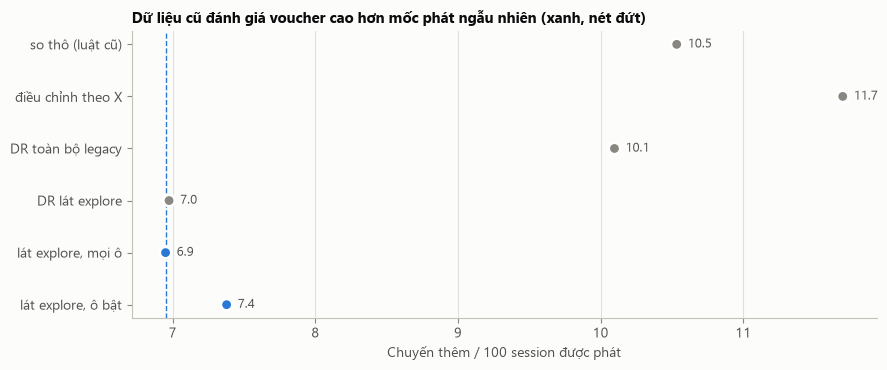

In [3]:
fig, ax = plt.subplots(figsize=(9, 3.8))
order = estimates.iloc[::-1].reset_index(drop=True)
y = np.arange(len(order))
colors = [C1 if name.startswith("lát explore") else MUTED for name in order["ước lượng"]]
ax.scatter(100 * order["hiệu ứng"], y, color=colors, s=70, zorder=3, edgecolor="white", linewidth=2)
ax.axvline(100 * est["explore_all"], color=C1, linewidth=1, linestyle="--")
for yi, v in zip(y, order["hiệu ứng"]):
    ax.annotate(f"{100 * v:.1f}", xy=(100 * v, yi), xytext=(8, 0), textcoords="offset points", va="center",
                color=INK_2, fontsize=9)
ax.set_yticks(y, order["ước lượng"])
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=GRID)
ax.set_xlabel("Chuyến thêm / 100 session được phát")
ax.set_title("Dữ liệu cũ đánh giá voucher cao hơn mốc phát ngẫu nhiên (xanh, nét đứt)")
fig.tight_layout()
save_figure(fig, "05_uoc_luong_legacy")

- So thô cao hơn lát explore khoảng 0,036 chuyến mỗi session, tức khoảng **một nửa** hiệu ứng thật.
- **Điều chỉnh theo X không gỡ được** độ lệch, thậm chí chệch hơn so thô (so với lát explore của ô bật); **DR-learner trên toàn bộ legacy** chỉ bớt một ít: cả hai chỉ điều chỉnh theo đặc trưng quan sát được, còn nguồn nhiễu là `u_latent`, không có trong dữ liệu.
- DR trên lát explore khớp lát explore vì ở đó voucher được phát ngẫu nhiên.

Đây là giả định "không có nhiễu ẩn" (unconfoundedness) mà mọi phương pháp dựa trên dữ liệu quan sát cần, kể cả DR-learner. Nó không kiểm tra được từ chính dữ liệu đó; trong mô phỏng ta kiểm được nhờ có lát explore và biến ẩn.

## 2. Cơ chế: luật cũ phát cho ai?

Chia rider thành 10 nhóm bằng nhau theo `u_latent` (đọc từ `hidden/`, chỉ để chẩn đoán).

In [4]:
profile = latent_profile(LEGACY, n_bins=10)
profile.round(4)

,bin,u_mid,sessions,share_offered,rate_not_offered,rate_offered,naive,explore_effect
0,0,-1.6563,72558,0.0513,0.0778,0.0972,0.0194,0.0226
1,1,-1.0509,71891,0.0910,0.0950,0.1231,0.0281,0.0327
2,2,-0.6899,71272,0.1223,0.1035,0.1412,0.0377,0.0553
3,3,-0.3981,73004,0.1554,0.1232,0.1655,0.0423,0.0602
4,4,-0.1432,72251,0.1863,0.1273,0.1805,0.0532,0.0600
5,5,0.1123,71177,0.2249,0.1252,0.1868,0.0616,0.0715
6,6,0.3728,71749,0.2560,0.1466,0.2183,0.0716,0.0810
7,7,0.6580,72191,0.3003,0.1503,0.2371,0.0868,0.0836
8,8,1.0335,69376,0.3529,0.1682,0.2685,0.1003,0.1077
9,9,1.6570,72445,0.4459,0.2073,0.3400,0.1327,0.1066


WindowsPath('D:/VSF_Intern/supply aware promotion uplift/docs/figures/05_co_che_u_latent.png')

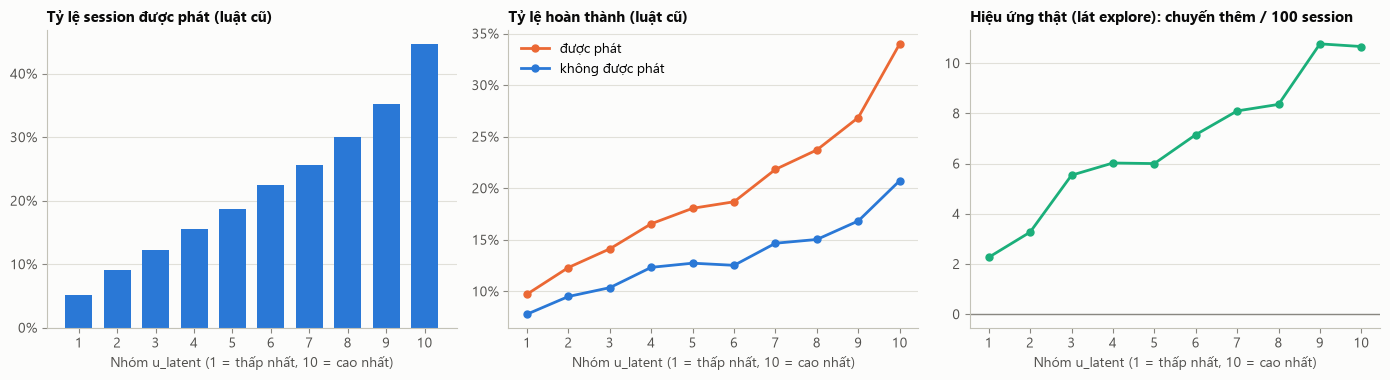

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.9))
x = profile["bin"] + 1
axes[0].bar(x, 100 * profile["share_offered"], color=C1, width=0.7)
axes[0].set_title("Tỷ lệ session được phát (luật cũ)")
axes[0].yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
for col, name, color in (("rate_offered", "được phát", C2), ("rate_not_offered", "không được phát", C1)):
    axes[1].plot(x, 100 * profile[col], color=color, linewidth=2, marker="o", markersize=5, label=name)
axes[1].set_title("Tỷ lệ hoàn thành (luật cũ)")
axes[1].legend(frameon=False, loc="upper left")
axes[1].yaxis.set_major_formatter(lambda v, _: f"{v:.0f}%")
axes[2].plot(x, 100 * profile["explore_effect"], color=C3, linewidth=2, marker="o", markersize=5)
axes[2].set_title("Hiệu ứng thật (lát explore): chuyến thêm / 100 session")
axes[2].axhline(0, color=MUTED, linewidth=1)
for ax in axes:
    ax.set_xlabel("Nhóm u_latent (1 = thấp nhất, 10 = cao nhất)")
    ax.set_xticks(x)
fig.tight_layout()
save_figure(fig, "05_co_che_u_latent")

Ba điều cùng lúc:
1. Luật cũ phát cho rider `u_latent` cao nhiều hơn hẳn (trái).
2. Rider `u_latent` cao hoàn thành chuyến nhiều hơn **kể cả khi không có voucher** (giữa, đường xanh).
3. Hiệu ứng thật của voucher cũng lớn hơn ở rider `u_latent` cao (phải).

(2) là **nhiễu chọn lọc**: so người được phát với người không được phát là so hai nhóm vốn khác nhau. (3) làm so thô đo *hiệu ứng trên người được phát* (ATT) thay vì *hiệu ứng trung bình* (ATE).

## 3. Tách độ lệch của so thô

Hai phần trên tách được bằng các hiệu ứng explore trong từng nhóm `u_latent` (`analysis.confounding.decompose_naive`).

In [6]:
parts = decompose_naive(profile)
parts.assign(**{"chuyến / 100 session": 100 * parts["value"]}).round(4)

,part,value,chuyến / 100 session
0,ate,0.0680,6.7955
1,targeting (att - ate),0.0137,1.3722
2,within-bin residual (naive_within_u - att),-0.0005,-0.0546
3,selection on u_latent (naive - naive_within_u),0.0242,2.4201
4,naive,0.1053,10.5332


WindowsPath('D:/VSF_Intern/supply aware promotion uplift/docs/figures/05_tach_do_lech.png')

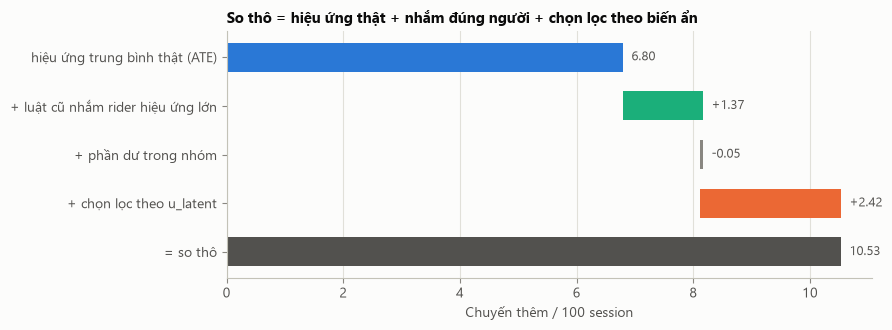

In [7]:
names = {"ate": "hiệu ứng trung bình thật (ATE)", "targeting (att - ate)": "+ luật cũ nhắm rider hiệu ứng lớn",
         "within-bin residual (naive_within_u - att)": "+ phần dư trong nhóm",
         "selection on u_latent (naive - naive_within_u)": "+ chọn lọc theo u_latent", "naive": "= so thô"}
fig, ax = plt.subplots(figsize=(9, 3.4))
values = 100 * parts["value"].to_numpy()
start = np.r_[0.0, np.cumsum(values[:3]), 0.0]
colors = [C1, C3, MUTED, C2, INK_2]
y = np.arange(len(values))[::-1]
ax.barh(y, values, left=start, color=colors, height=0.6)
for yi, s, v in zip(y, start, values):
    ax.annotate(f"{v:+.2f}" if 0 < yi < len(values) - 1 else f"{v:.2f}", xy=(s + max(v, 0), yi), xytext=(6, 0),
                textcoords="offset points", va="center", color=INK_2, fontsize=9)
ax.set_yticks(y, [names[p] for p in parts["part"]])
ax.grid(axis="y", visible=False)
ax.grid(axis="x", color=GRID)
ax.set_xlabel("Chuyến thêm / 100 session")
ax.set_title("So thô = hiệu ứng thật + nhắm đúng người + chọn lọc theo biến ẩn")
fig.tight_layout()
save_figure(fig, "05_tach_do_lech")

- Phần "nhắm rider hiệu ứng lớn" **không phải sai số**: nếu câu hỏi là "voucher giúp *những người luật cũ đã phát* bao nhiêu" thì ATT là đáp án đúng. Nó chỉ sai khi dùng để dự đoán cho một chính sách phát cho người khác.
- Phần "chọn lọc theo `u_latent`" là **độ chệch thật**: người được phát đằng nào cũng hay đi xe hơn. Không phương pháp nào trên dữ liệu quan sát loại được phần này, vì `u_latent` bị ẩn.
- Trong cùng một nhóm `u_latent`, so thô gần bằng hiệu ứng thật: nếu quan sát được `u_latent` thì điều chỉnh theo nó là đủ.

## 4. Độ lệch theo độ mạnh của việc nhắm `u_latent`

Sinh lại dữ liệu cũ với cùng 718.749 session (CRN), chỉ đổi hệ số nhắm `policy.legacy.target_g_u`: 0 (không nhắm theo `u_latent`), 0,5, 1 (mặc định), 2. Dữ liệu và cách đo là của T5.3 (Tình, T-34); notebook 03 trình bày cùng số liệu dưới góc độ thiết kế thí nghiệm.

In [8]:
sens = confounding_table([GU_0, GU_05, LEGACY, GU_2], n_boot=200)
split = pd.DataFrame({g: decompose_naive(latent_profile(d)).set_index("part")["value"]
                      for g, d in zip(sens["target_g_u"], (GU_0, GU_05, LEGACY, GU_2))}).T
sens = sens.set_index("target_g_u").join(split.drop(columns="naive"))   # same naive as the table
sens[["share_offered", "naive", "explore_all", "bias_naive", "adjusted", "explore_on", "bias_adjusted",
      "selection on u_latent (naive - naive_within_u)", "targeting (att - ate)"]].round(4)

,share_offered,naive,explore_all,bias_naive,adjusted,explore_on,bias_adjusted,selection on u_latent (naive - naive_within_u),targeting (att - ate)
target_g_u,,,,,,,,,
0.0,0.2055,0.0608,0.0700,-0.0092,0.0682,0.0734,-0.0052,0.0001,0.0001
0.5,0.2075,0.0848,0.0666,0.0182,0.0949,0.0739,0.0210,0.0140,0.0085
1.0,0.2181,0.1053,0.0695,0.0358,0.1170,0.0738,0.0432,0.0242,0.0137
2.0,0.2154,0.1224,0.0580,0.0644,0.1306,0.0582,0.0724,0.0318,0.0186


WindowsPath('D:/VSF_Intern/supply aware promotion uplift/docs/figures/05_do_nhay_u_latent.png')

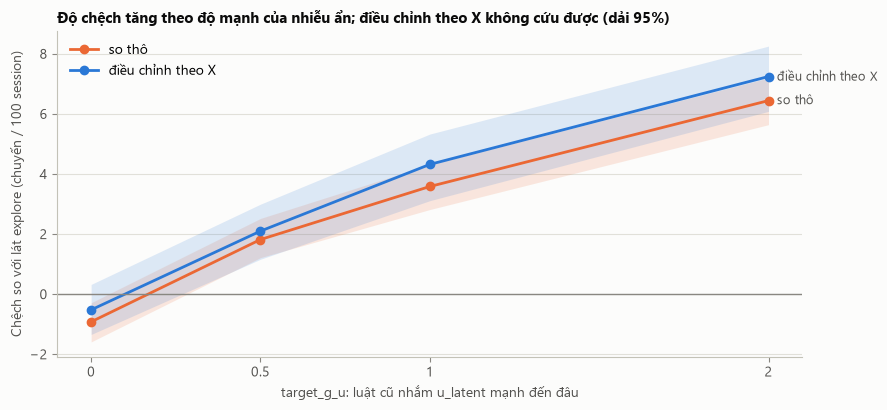

In [9]:
fig, ax = plt.subplots(figsize=(9, 4.2))
g = sens.index.to_numpy()
for col, name, color in (("bias_naive", "so thô", C2), ("bias_adjusted", "điều chỉnh theo X", C1)):
    ax.fill_between(g, 100 * sens[f"{col}_lo"], 100 * sens[f"{col}_hi"], color=color, alpha=0.15, linewidth=0)
    ax.plot(g, 100 * sens[col], color=color, linewidth=2, marker="o", markersize=6, label=name)
    ax.annotate(name, xy=(g[-1], 100 * sens[col].iloc[-1]), xytext=(6, 0), textcoords="offset points",
                va="center", color=INK_2, fontsize=9)
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_xticks(g, [f"{v:g}" for v in g])
ax.set_xlabel("target_g_u: luật cũ nhắm u_latent mạnh đến đâu")
ax.set_ylabel("Chệch so với lát explore (chuyến / 100 session)")
ax.legend(frameon=False, loc="upper left")
ax.set_title("Độ chệch tăng theo độ mạnh của nhiễu ẩn; điều chỉnh theo X không cứu được (dải 95%)")
fig.tight_layout()
save_figure(fig, "05_do_nhay_u_latent")

- Khi luật cũ **không** nhắm theo `u_latent` (`target_g_u` = 0), điều chỉnh theo X gần như hết chệch: nhiễu còn lại chỉ là nhiễu quan sát được.
- Nhắm càng mạnh thì chệch sau điều chỉnh càng lớn, gần tuyến tính, và phần "chọn lọc theo `u_latent`" của mục 3 tăng theo. Với mức mặc định (1), chệch sau điều chỉnh đã hơn một nửa hiệu ứng thật.

## 5. Kết luận

1. Trên dữ liệu cũ, **so thô, điều chỉnh theo X và DR-learner đều đánh giá voucher cao hơn thật khoảng 45–60%**, vì luật cũ nhắm theo biến ẩn `u_latent`. DR-learner chỉ sửa được nhiễu *quan sát được*.
2. Độ lệch gồm hai phần: luật cũ nhắm đúng rider có hiệu ứng lớn (ATT ≠ ATE, không phải sai số nếu hỏi đúng câu) và chọn lọc theo `u_latent` (sai số thật, không gỡ được từ dữ liệu quan sát).
3. **Cách khắc phục là dữ liệu ngẫu nhiên hóa**: lát explore 5% đã đủ cho một ước lượng không chệch của hiệu ứng trung bình. Thí nghiệm A/B và switchback (notebook 03) đo hiệu ứng tổng nhưng có vấn đề riêng là interference.
4. Hệ quả cho chính sách (notebook 04): hàm điểm `tau_x_dr_all_per_dollar`, học trên toàn bộ legacy, vẫn cho nhiều chuyến nhất dưới B. Chính sách chỉ cần **thứ hạng** rider, không cần mức hiệu ứng đúng; kết quả dưới B cho thấy độ chệch không làm hỏng thứ hạng theo chuyến thêm mỗi USD đến mức thua các hàm điểm khác. Mọi con số "voucher thêm bao nhiêu chuyến" phải lấy từ dữ liệu ngẫu nhiên hóa, không từ dữ liệu cũ.